# Recommender System Exploration and Analysis

Import and NoteBook Setup

In [2]:
#install repo library
!pip install kagglehub

In [1]:
# Import initial 3rd party libraries
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import json

# Configure Notebook
# %matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_context("notebook")
# Force white background after fivethirtyeight
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style("whitegrid")        # or "white"
sns.despine(left=True, bottom=True)
import warnings
warnings.filterwarnings('ignore')

c:\python3_12\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 640x480 with 0 Axes>

### Load the Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7


In [3]:
import os

for root, dirs, files in os.walk(path):
    print(f"Directory: {root}")
    for file in files:
        file_path = os.path.join(root, file)
        print(f"  File: {file_path}")
        print(file)
        

Directory: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\credits.csv
credits.csv
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\keywords.csv
keywords.csv
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\links.csv
links.csv
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\links_small.csv
links_small.csv
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\movies_metadata.csv
movies_metadata.csv
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\ratings.csv
ratings.csv
  File: C:\Users\mavla\.cache\kagglehub\datasets\rounakbanik\the-movies-dataset\versions\7\ratings_small.csv
ratings_small.csv


### Load the files and do basic cleaning  
To run with the large dataset, remove the '_small' from the ratings and links file string

In [4]:
# Load the metadata
# data_path = "../../datasets/input/"
data_path = path+"\\"
df_meta = pd.read_csv(data_path+"movies_metadata.csv")
df_meta = df_meta[["id", "title"]]
df_meta["id"] = pd.to_numeric(df_meta["id"], errors="coerce") 
df_meta = df_meta.dropna(subset=["id"]).astype({"id": int}) 
df_meta = df_meta.dropna(subset=["title"]) 
df_meta = df_meta.drop_duplicates(subset=['id'],keep='first')

# Load the ratings dataset
df_ratings = pd.read_csv(data_path+"ratings_small.csv")
df_ratings = df_ratings[["userId", "movieId", "rating"]]
df_ratings = df_ratings.dropna(subset=["userId", "movieId", "rating"])
df_ratings["userId"] = df_ratings["userId"].astype(int) 
df_ratings["movieId"] = df_ratings["movieId"].astype(int) 
df_ratings["rating"] = df_ratings["rating"].astype(float) 
# If there are duplicate <userId, movieId> pairs, average them. Unlikely though 
df_ratings = df_ratings.groupby(["userId", "movieId"], as_index=False)["rating"].mean()


df_links = pd.read_csv(data_path+"links_small.csv") 
df_links = df_links[["movieId", "tmdbId"]]
df_links["tmdbId"] = pd.to_numeric(df_links["tmdbId"], errors="coerce") 
df_links = df_links.dropna(subset=["tmdbId"]).astype({"tmdbId": int}) 

### Filter outliers and users who have few ratings  
These users can skew the data and introduce noise in the system

In [ ]:
user_counts = df_ratings['userId'].value_counts().sort_index()

plot_df = pd.DataFrame({
    'userId': user_counts.index,
    'rating_count': user_counts.values
})

<Axes: xlabel='userId', ylabel='rating_count'>

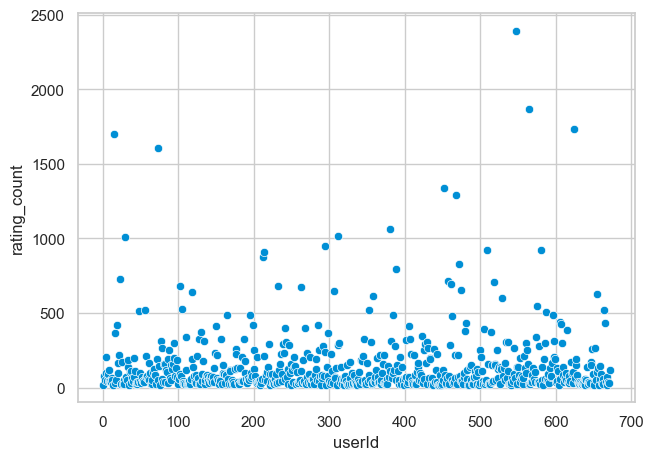

In [17]:
sns.scatterplot(plot_df,x='userId',y='rating_count')

In [24]:
# Filter users who have rated too many or too few movies
print("="*50)
print("FILTER USERS")
print("="*50)

# Count how many movies each user has rated
user_movie_counts = df_ratings['userId'].value_counts()
print(f"User rating counts - Min: {user_movie_counts.min()}, Max: {user_movie_counts.max()}")

# Remove users who have rated less than 5 movies (10  for full dataset)
min_user_ratings = 5
users_to_keep = user_movie_counts[user_movie_counts >= min_user_ratings].index
print(f"Users with at least {min_user_ratings} ratings: {len(users_to_keep)} out of {len(user_movie_counts)}")

# Remove users who rated too many movies (top 5% likely outliers)
max_percentile = 95
max_user_ratings = np.percentile(user_movie_counts, max_percentile)
users_to_keep = users_to_keep[user_movie_counts[users_to_keep] <= max_user_ratings]
print(f"Users after removing top 5% (>{max_user_ratings:.0f} ratings): {len(users_to_keep)}")

# Filter the dataset to keep only selected users
ratings_filtered = df_ratings[df_ratings['userId'].isin(users_to_keep)].copy()
print(f"Ratings after user filtering: {ratings_filtered.shape}")


FILTER USERS
User rating counts - Min: 20, Max: 2391
Users with at least 5 ratings: 671 out of 671
Users after removing top 5% (>520 ratings): 637
Ratings after user filtering: (67995, 3)


### Filter movies with few ratings 
These movies introduce noise in the system and increase computation memory

In [21]:
movie_counts = df_ratings['movieId'].value_counts().sort_index()

plot_df = pd.DataFrame({
    'movieId': movie_counts.index,
    'rating_count': movie_counts.values
})

<Axes: xlabel='movieId', ylabel='rating_count'>

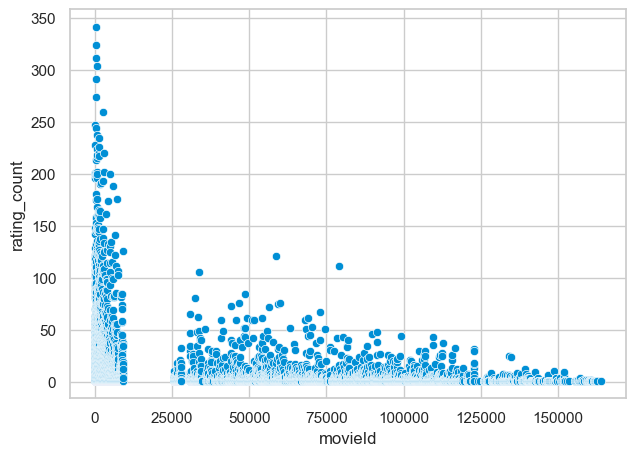

In [22]:
sns.scatterplot(plot_df,x='movieId',y='rating_count')

In [ ]:
# Filter movies with less than 20 ratings

print("="*50)
print("FILTERING MOVIES")
print("="*50)

# Count how many ratings each movie has received
movie_rating_counts = ratings_filtered['movieId'].value_counts()
print(f"Movie rating counts - Min: {movie_rating_counts.min()}, Max: {movie_rating_counts.max()}")

# Keep only movies with at least 20 ratings
min_movie_ratings = 20
movies_to_keep = movie_rating_counts[movie_rating_counts >= min_movie_ratings].index
print(f"Movies with at least {min_movie_ratings} ratings: {len(movies_to_keep)} out of {len(movie_rating_counts)}")

# Filter the dataset to keep only selected movies
ratings_final = ratings_filtered[ratings_filtered['movieId'].isin(movies_to_keep)].copy()
print(f"Final ratings shape: {ratings_final.shape}")


STEP 2: FILTERING MOVIES
Movie rating counts - Min: 1, Max: 308
Movies with at least 20 ratings: 846 out of 6800
Final ratings shape: (44920, 3)


### Create the index mappings  
Since users and movies were removed they are no longer sequential and have gaps.
The mappings will keep track of the real id's after the computations

In [ ]:
# Create index mappings
print("="*50)
print("CREATING INDEX MAPPINGS")
print("="*50)

unique_users = sorted(ratings_final['userId'].unique())
unique_movies = sorted(ratings_final['movieId'].unique())

print(f"Final number of users: {len(unique_users)}")
print(f"Final number of movies: {len(unique_movies)}")

user_id_to_index = {user_id: idx for idx, user_id in enumerate(unique_users)}
index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(unique_movies)}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

ratings_final['user_idx'] = ratings_final['userId'].map(user_id_to_index)
ratings_final['movie_idx'] = ratings_final['movieId'].map(movie_id_to_index)

CREATING INDEX MAPPINGS
Final number of users: 637
Final number of movies: 846
Index mappings created successfully!


### Create the sparse User-Item matrix

In [27]:
# Create the user-movie rating matrix
print("="*50)
print("CREATING USER-MOVIE MATRIX")
print("="*50)

from scipy.sparse import csr_matrix

n_users = len(unique_users)
n_movies = len(unique_movies)

# Convert to numpy arrays for faster indexing
user_indices = ratings_final['user_idx'].values.astype(int)
movie_indices = ratings_final['movie_idx'].values.astype(int)
rating_values = ratings_final['rating'].values.astype(float)

# Create a sparse user-movie matrix using csr_matrix
# Data, (row_indices, col_indices)
user_movie_matrix = csr_matrix((rating_values, (user_indices, movie_indices)), shape=(n_users, n_movies))

print(f"User-movie matrix shape: {user_movie_matrix.shape}")
# Sparsity for csr_matrix can be calculated as 1 - (number of stored elements / total possible elements)
print(f"Matrix sparsity: {(1 - user_movie_matrix.nnz / (n_users * n_movies)) * 100:.2f}%")

CREATING USER-MOVIE MATRIX
User-movie matrix shape: (637, 846)
Matrix sparsity: 91.66%


### Load surprise library for model analysis

In [28]:
from surprise import Dataset, Reader, accuracy
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
from surprise import SVD, NMF, CoClustering, KNNBasic, KNNWithMeans, KNNWithZScore, SlopeOne
import pandas as pd
import numpy as np

reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings_final[['userId', 'movieId', 'rating']], reader)


### Run 5 cross-fold validation on each model to check initial performance


In [29]:
# SVD

algo=svd= SVD()
svd_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)


Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8692  0.8725  0.8554  0.8721  0.8660  0.8671  0.0063  
MAE (testset)     0.6616  0.6641  0.6549  0.6683  0.6584  0.6615  0.0046  
Fit time          0.18    0.17    0.15    0.13    0.15    0.16    0.02    
Test time         0.01    0.02    0.10    0.02    0.02    0.03    0.03    


In [30]:
# User based kNN

algo=kNNBasic_user= KNNBasic(sim_options={'user_based': True})
kNNBasicUser_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9173  0.9017  0.9021  0.8906  0.9104  0.9044  0.0090  
MAE (testset)     0.6974  0.6891  0.6822  0.6766  0.6944  0.6879  0.0076  
Fit time          0.05    0.05    0.05    0.05    0.05    0.05    0.00    
Test time         0.25    0.32    0.31    0.26    0.26    0.28    0.03    


In [31]:
# Item based kNN

algo=kNNBasic_item= KNNBasic(sim_options={'user_based': False})
kNNBasicItem_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8876  0.9018  0.9041  0.8811  0.8822  0.8914  0.0097  
MAE (testset)     0.6851  0.6863  0.6918  0.6774  0.6730  0.6827  0.0067  
Fit time          0.06    0.07    0.08    0.07    0.08    0.07    0.00    
Test time         0.35    0.43    0.38    0.40    0.37    0.39    0.03    


Graph the results

In [ ]:
dplot = {
    'SVD':svd_cv_results,
    'User CF':kNNBasicUser_cv_results,
    'Item CF':kNNBasicItem_cv_results,
}
df_list = []

for model_name, result in dplot.items():
    dfdl = pd.DataFrame({
        'test_rmse': result['test_rmse'],
        'test_mae':  result['test_mae'],
        'fit_time':  result['fit_time'],
        'test_time': result['test_time']
    })
    dfdl['model'] = model_name
    df_list.append(dfdl)

# Combine all folds from all models
df_all = pd.concat(df_list, ignore_index=True)

# Reorder columns
df_all = df_all[['model', 'test_rmse', 'test_mae', 'fit_time', 'test_time']]

print(df_all.round(5))

      model  test_rmse  test_mae  fit_time  test_time
0       SVD    0.86916   0.66164   0.18342    0.01452
1       SVD    0.87253   0.66410   0.17112    0.01553
2       SVD    0.85545   0.65491   0.15007    0.10151
3       SVD    0.87214   0.66832   0.12869    0.01502
4       SVD    0.86604   0.65844   0.14634    0.01783
5   User CF    0.91729   0.69735   0.04534    0.25420
6   User CF    0.90168   0.68912   0.05361    0.32106
7   User CF    0.90207   0.68224   0.04819    0.30721
8   User CF    0.89061   0.67665   0.04993    0.26162
9   User CF    0.91044   0.69439   0.05022    0.25748
10  Item CF    0.88763   0.68509   0.06317    0.34997
11  Item CF    0.90179   0.68634   0.06616    0.43377
12  Item CF    0.90408   0.69176   0.07528    0.38166
13  Item CF    0.88113   0.67744   0.07150    0.40107
14  Item CF    0.88217   0.67299   0.07514    0.36678


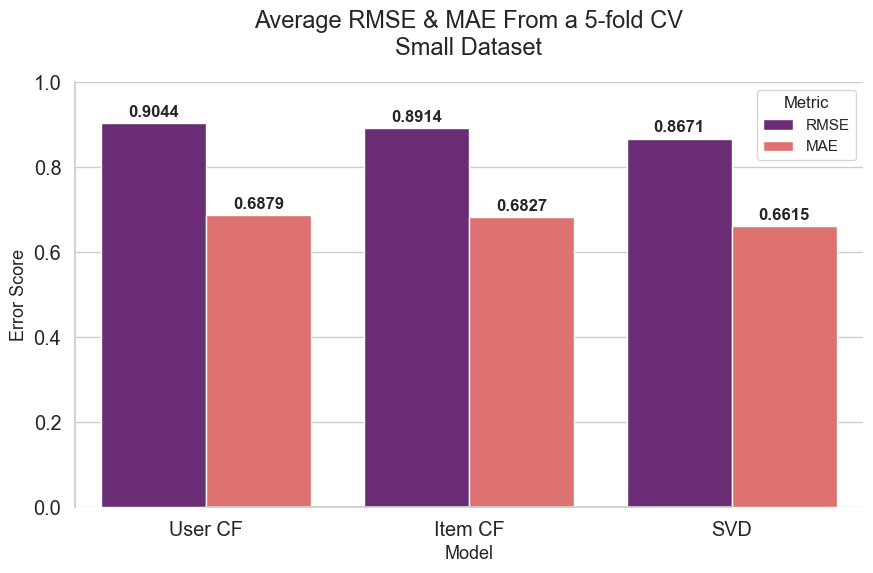

In [38]:
# Calc average RMSE and MAE per model ---
means = df_all.groupby('model')[['test_rmse', 'test_mae']].mean().round(4)
means = means.reset_index()

# Melt to long format for seaborn plot
plot_df = means.melt(id_vars='model',
                     value_vars=['test_rmse', 'test_mae'],
                     var_name='Metric',
                     value_name='Score')

# Make names nicer
plot_df['Metric'] = plot_df['Metric'].replace({
    'test_rmse': 'RMSE',
    'test_mae':  'MAE'
})

# Order models
model_order = ['User CF', 'Item CF', 'SVD']  # or whatever order you prefer
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df = plot_df.sort_values('model')


# Plot
plt.figure(figsize=(9, 6))
sns.set_context("notebook", font_scale=1.3)
ax = sns.barplot(data=plot_df,
                 x='model',
                 y='Score',
                 hue='Metric',
                 palette='magma')

# Add values on top of each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0.01:
            ax.text(p.get_x() + p.get_width()/2.,
                    height + 0.008,
                    f'{height:.4f}',
                    ha='center', va='bottom',
                    fontweight='bold', fontsize=12)

ax.set_title('Average RMSE & MAE From a 5-fold CV\nSmall Dataset',
             fontsize=17, pad=20)
ax.set_ylabel('Error Score', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.legend(title='Metric', title_fontsize=12, fontsize=11, loc='upper right')

plt.ylim(0, 1.0)
sns.despine(trim=True)
plt.tight_layout()
plt.show()

### Try with taking into account user and movie mean ratings
This should balance the data and deal with users who rate high or low all the time  
Should also deal with popular movies to offer more unique selections

In [36]:
# User based kNN taking into account the mean ratings of each user

algo = kNNWithMeans_user= KNNWithMeans(sim_options={'user_based': True})
kNNMeansUser_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8604  0.8729  0.8690  0.8737  0.8654  0.8683  0.0049  
MAE (testset)     0.6542  0.6619  0.6608  0.6672  0.6586  0.6605  0.0042  
Fit time          0.07    0.06    0.06    0.05    0.06    0.06    0.01    
Test time         0.34    0.30    0.28    0.43    0.30    0.33    0.05    


In [37]:
# Item based kNN taking into account the mean ratings of each user

algo=kNNWithMeans_item= KNNWithMeans(sim_options={'user_based': False})
kNNMeansItem_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8572  0.8598  0.8577  0.8541  0.8638  0.8585  0.0032  
MAE (testset)     0.6505  0.6557  0.6520  0.6526  0.6551  0.6532  0.0019  
Fit time          0.07    0.08    0.09    0.08    0.08    0.08    0.01    
Test time         0.41    0.46    0.47    0.42    0.47    0.45    0.02    


Make the plots again  
Use line graph as bars get hard to see when the values are close

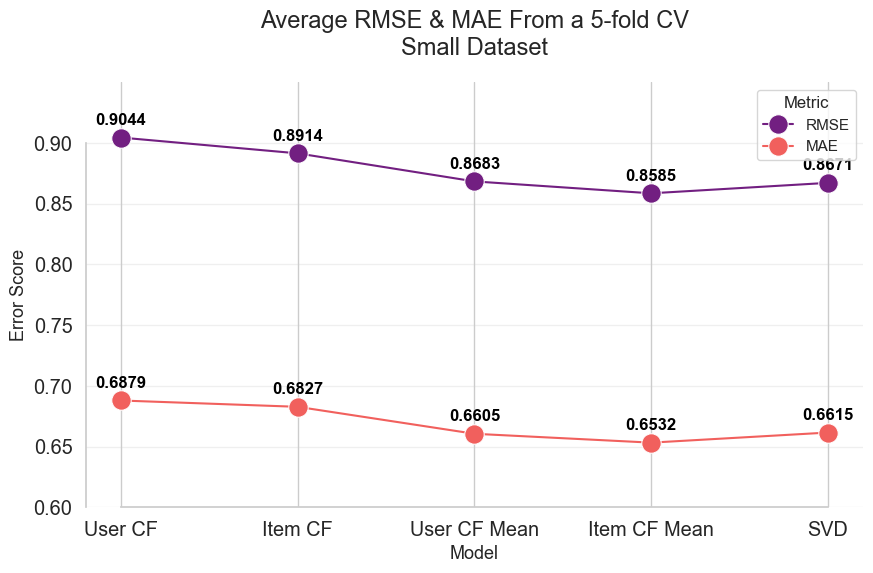

In [40]:
dplot = {
    'SVD':      svd_cv_results,
    'User CF':kNNBasicUser_cv_results,
    'Item CF':kNNBasicItem_cv_results,
    'User CF Mean':kNNMeansUser_cv_results,
    'Item CF Mean':kNNMeansItem_cv_results
}

df_list = []
for model_name, result in dplot.items():
    df_temp = pd.DataFrame({
        'test_rmse': result['test_rmse'],
        'test_mae':  result['test_mae']
    })
    df_temp['model'] = model_name
    df_list.append(df_temp)

df_all = pd.concat(df_list, ignore_index=True)

# Calc average per model
means = df_all.groupby('model')[['test_rmse', 'test_mae']].mean().round(4)
means = means.reset_index()

# Melt to long format again
plot_df = means.melt(id_vars='model',
                     value_vars=['test_rmse', 'test_mae'],
                     var_name='Metric',
                     value_name='Score')

# Clean names
plot_df['Metric'] = plot_df['Metric'].replace({'test_rmse': 'RMSE', 'test_mae': 'MAE'})

# Order models
model_order = ['User CF', 'Item CF','User CF Mean', 'Item CF Mean', 'SVD']
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df = plot_df.sort_values('model')

# Use a line graph this time
plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

# Lineplot with markers
ax = sns.lineplot(data=plot_df,
                  x='model',
                  y='Score',
                  hue='Metric',
                  marker='o',
                  markersize=14,
                  palette='magma')

# Add values next to each point
for _, row in plot_df.iterrows():
    ax.text(row['model'], 
            row['Score'] + 0.008,
            f'{row["Score"]:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=12, color='black')

ax.set_title('Average RMSE & MAE From a 5-fold CV\nSmall Dataset',
             fontsize=17, pad=20)
ax.set_ylabel('Error Score', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.legend(title='Metric', title_fontsize=12, fontsize=11, loc='upper right')

plt.ylim(0.60, 0.95)
sns.despine(trim=True)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Another line plot, but with some metrics from the full dataset  
Manually entered since cross-fold valuation on the full set takes a long time. Values came from the full dataset run

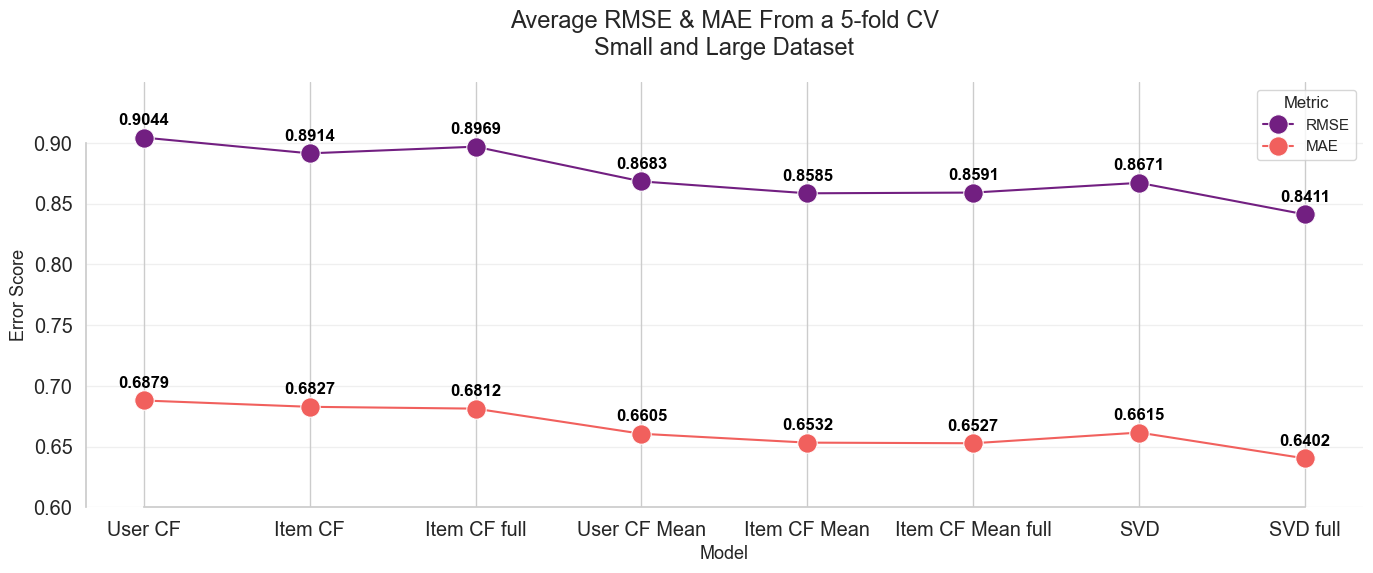

In [41]:
dplot = {
    'SVD':      svd_cv_results,
    'SVD full':      {
        'test_rmse': np.array([0.8410 , 0.8415 , 0.8417,  0.8397,  0.8417]),
        'test_mae':  np.array([ 0.6398,  0.6404 , 0.6407,  0.6393,  0.6406]),
        'fit_time':  (  56.81,   64.98,   66.71,   66.90 ,  66.79),
        'test_time': ( 361.53,  26.48 ,  31.38 ,  21.22,   19.34 )
        },
    'User CF':kNNBasicUser_cv_results,
    'Item CF':kNNBasicItem_cv_results,
    'Item CF full':{
        'test_rmse': np.array([0.8971,  0.8974,  0.8963,  0.8968,  0.8967]),
        'test_mae':  np.array([ 0.6813,  0.6814,  0.6808,  0.6812,  0.6811 ]),
        'fit_time':  ( 33.35,   35.85,   34.41,   33.33,   34.83),
        'test_time': ( 139.70,  201.47,  150.90,  161.40,  156.74 )
        },
    'User CF Mean':kNNMeansUser_cv_results,
    'Item CF Mean':kNNMeansItem_cv_results,
    'Item CF Mean full':{
        'test_rmse': np.array([0.8587,  0.8589,  0.8591,  0.8590,  0.8599]),
        'test_mae':  np.array([ 0.6525,  0.6525,  0.6525,  0.6525,  0.6533]),
        'fit_time':  ( 34.41,   37.14,   37.16,   36.54,   32.35),
        'test_time': (461.38,  178.71,  241.97, 389.37,  279.53 )
        }
}

df_list = []
for model_name, result in dplot.items():
    df_temp = pd.DataFrame({
        'test_rmse': result['test_rmse'],
        'test_mae':  result['test_mae']
    })
    df_temp['model'] = model_name
    df_list.append(df_temp)

df_all = pd.concat(df_list, ignore_index=True)

# Calc average per model
means = df_all.groupby('model')[['test_rmse', 'test_mae']].mean().round(4)
means = means.reset_index()

# Melt to long format
plot_df = means.melt(id_vars='model',
                     value_vars=['test_rmse', 'test_mae'],
                     var_name='Metric',
                     value_name='Score')

# Clean names
plot_df['Metric'] = plot_df['Metric'].replace({'test_rmse': 'RMSE', 'test_mae': 'MAE'})

# Order models
model_order = ['User CF', 'Item CF','Item CF full','User CF Mean', 'Item CF Mean', 'Item CF Mean full', 'SVD', 'SVD full']  # or whatever order you prefer
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df = plot_df.sort_values('model')

plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

# Lineplot with markers
ax = sns.lineplot(data=plot_df,
                  x='model',
                  y='Score',
                  hue='Metric',
                  marker='o',
                  markersize=14,
                  palette='magma')

# Add values next to each point
for _, row in plot_df.iterrows():
    ax.text(row['model'], 
            row['Score'] + 0.008,
            f'{row["Score"]:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=12, color='black')

ax.set_title('Average RMSE & MAE From a 5-fold CV\nSmall and Large Dataset',
             fontsize=17, pad=20)
ax.set_ylabel('Error Score', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.legend(title='Metric', title_fontsize=12, fontsize=11, loc='upper right')

plt.ylim(0.60, 0.95)  
sns.despine(trim=True)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Graph the fit times of the full dataset. The small dataset is commented out. Uncomment them to include  
If graphing the small dataset fit times it is a good idea not to include the full dataset times

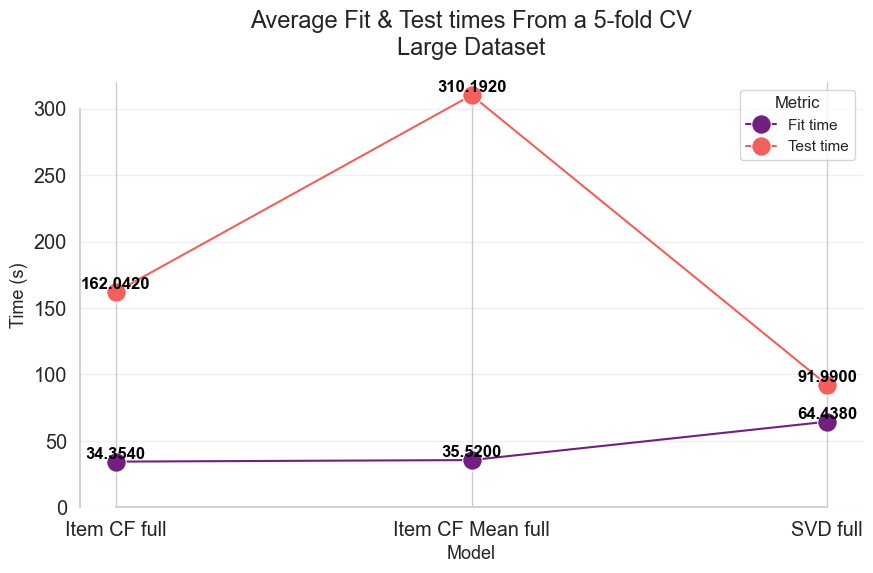

In [42]:
dplot = {
    # 'SVD':      svd_cv_results,
    'SVD full':      {
        'test_rmse': np.array([0.8410 , 0.8415 , 0.8417,  0.8397,  0.8417]),
        'test_mae':  np.array([ 0.6398,  0.6404 , 0.6407,  0.6393,  0.6406]),
        'fit_time':  (  56.81,   64.98,   66.71,   66.90 ,  66.79),
        'test_time': ( 361.53,  26.48 ,  31.38 ,  21.22,   19.34 )
        },
    # 'User CF':kNNBasicUser_cv_results,
    # 'Item CF':kNNBasicItem_cv_results,
    'Item CF full':{
        'test_rmse': np.array([0.8971,  0.8974,  0.8963,  0.8968,  0.8967]),
        'test_mae':  np.array([ 0.6813,  0.6814,  0.6808,  0.6812,  0.6811 ]),
        'fit_time':  ( 33.35,   35.85,   34.41,   33.33,   34.83),
        'test_time': ( 139.70,  201.47,  150.90,  161.40,  156.74 )
        },
    # 'User CF Mean':kNNMeansUser_cv_results,
    # 'Item CF Mean':kNNMeansItem_cv_results,
    'Item CF Mean full':{
        'test_rmse': np.array([0.8587,  0.8589,  0.8591,  0.8590,  0.8599]),
        'test_mae':  np.array([ 0.6525,  0.6525,  0.6525,  0.6525,  0.6533]),
        'fit_time':  ( 34.41,   37.14,   37.16,   36.54,   32.35),
        'test_time': (461.38,  178.71,  241.97, 389.37,  279.53 )
        }
}

df_list = []
for model_name, result in dplot.items():
    df_temp = pd.DataFrame({
        'fit_time': result['fit_time'],
        'test_time':  result['test_time']
    })
    df_temp['model'] = model_name
    df_list.append(df_temp)

df_all = pd.concat(df_list, ignore_index=True)

# Calc average per model
means = df_all.groupby('model')[['fit_time', 'test_time']].mean().round(4)
means = means.reset_index()

# Melt to long format
plot_df = means.melt(id_vars='model',
                     value_vars=['fit_time', 'test_time'],
                     var_name='Metric',
                     value_name='Time')

# Clean names
plot_df['Metric'] = plot_df['Metric'].replace({'fit_time': 'Fit time', 'test_time': 'Test time'})

# model_order = ['User CF', 'Item CF','User CF Mean', 'Item CF Mean', 'SVD'] 
model_order = ['Item CF full', 'Item CF Mean full', 'SVD full'] 
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df = plot_df.sort_values('model')

plt.figure(figsize=(9, 6))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

# Lineplot with markers
ax = sns.lineplot(data=plot_df,
                  x='model',
                  y='Time',
                  hue='Metric',
                  marker='o',
                  markersize=14,
                  palette='magma')

# Add values next to each point
for _, row in plot_df.iterrows():
    ax.text(row['model'], 
            row['Time'] + 0.008,
            f'{row["Time"]:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=12, color='black')

ax.set_title('Average Fit & Test times From a 5-fold CV\nLarge Dataset',
             fontsize=17, pad=20)
ax.set_ylabel('Time (s)', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.legend(title='Metric', title_fontsize=12, fontsize=11, loc='upper right')

plt.ylim(0, 320)
sns.despine(trim=True)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Attempted with z-score, but found little improvement

In [ ]:
# User based kNN taking into account the z-score normalization of each user

algo=kNNWithZScore_user= KNNWithZScore(sim_options={'user_based': True})
kNNzUser_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8726  0.8689  0.8680  0.8614  0.8811  0.8704  0.0065  
MAE (testset)     0.6574  0.6591  0.6550  0.6532  0.6708  0.6591  0.0062  
Fit time          0.05    0.06    0.05    0.06    0.06    0.06    0.00    
Test time         0.25    0.26    0.25    0.25    0.26    0.25    0.01    


In [84]:
# Item based kNN taking into account the z-score normalization of each user

algo=kNNWithZScore_item= KNNWithZScore(sim_options={'user_based': False})
kNNzItem_cv_results = cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Evaluating RMSE, MAE of algorithm KNNWithZScore on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8592  0.8866  0.8412  0.8660  0.8538  0.8614  0.0150  
MAE (testset)     0.6500  0.6714  0.6419  0.6595  0.6517  0.6549  0.0100  
Fit time          0.08    0.08    0.08    0.07    0.07    0.07    0.00    
Test time         0.35    0.34    0.33    0.34    0.33    0.34    0.01    


## Hypertuning

In [ ]:
# Tuning

# SVD
# grid search
print("SVD Grid Search")

param_grid = {
    "n_factors":[50,100,150,200],
    "n_epochs": [5, 10, 15, 20, 25,30], 
    "lr_all": [0.002, 0.005, 0.007]
    }

grid_search = GridSearchCV(SVD, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
svd_algo = grid_search.best_estimator["rmse"]

svd_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
svd_results_df.head()


SVD Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_factors,param_n_epochs,param_lr_all
0,0.910396,0.905721,0.911726,0.909281,0.002575,69,0.027548,0.004156,0.032683,0.007304,"{'n_factors': 50, 'n_epochs': 5, 'lr_all': 0.002}",50,5,0.002
1,0.881794,0.877481,0.885383,0.881553,0.003230,55,0.019185,0.001026,0.026322,0.000628,"{'n_factors': 50, 'n_epochs': 5, 'lr_all': 0.005}",50,5,0.005
2,0.875897,0.872082,0.879851,0.875943,0.003172,28,0.018129,0.000447,0.064085,0.056658,"{'n_factors': 50, 'n_epochs': 5, 'lr_all': 0.007}",50,5,0.007
3,0.888178,0.882549,0.889565,0.886764,0.003034,63,0.034848,0.001202,0.027032,0.001875,"{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0....",50,10,0.002
4,0.872234,0.868721,0.875217,0.872057,0.002655,11,0.036575,0.003962,0.025868,0.000240,"{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0....",50,10,0.005


In [159]:
svd_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_n_factors,param_n_epochs,param_lr_all
7,0.867842,0.864215,0.875832,0.869296,0.004853,1,0.050921,0.001302,0.063023,0.052486,"{'n_factors': 50, 'n_epochs': 15, 'lr_all': 0....",50,15,0.005
10,0.866672,0.865894,0.876239,0.869602,0.004704,2,0.064205,0.000184,0.063051,0.050156,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",50,20,0.005
5,0.869102,0.864976,0.874839,0.869639,0.004045,3,0.035253,0.001709,0.065137,0.054632,"{'n_factors': 50, 'n_epochs': 10, 'lr_all': 0....",50,10,0.007
8,0.868215,0.865221,0.876444,0.869960,0.004745,4,0.051901,0.001655,0.027443,0.001814,"{'n_factors': 50, 'n_epochs': 15, 'lr_all': 0....",50,15,0.007
11,0.867247,0.866528,0.876353,0.870043,0.004471,5,0.066556,0.000812,0.026120,0.000938,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0....",50,20,0.007


In [234]:
svd_cv_results_h = cross_validate(svd_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8676  0.8588  0.8616  0.8556  0.8717  0.8631  0.0059  
MAE (testset)     0.6594  0.6554  0.6620  0.6534  0.6644  0.6589  0.0041  
Fit time          0.12    0.15    0.20    0.10    0.10    0.14    0.04    
Test time         0.03    0.03    0.02    0.02    0.02    0.03    0.00    


Plot parameter change effects

<Axes: xlabel='param_n_factors', ylabel='mean_test_rmse'>

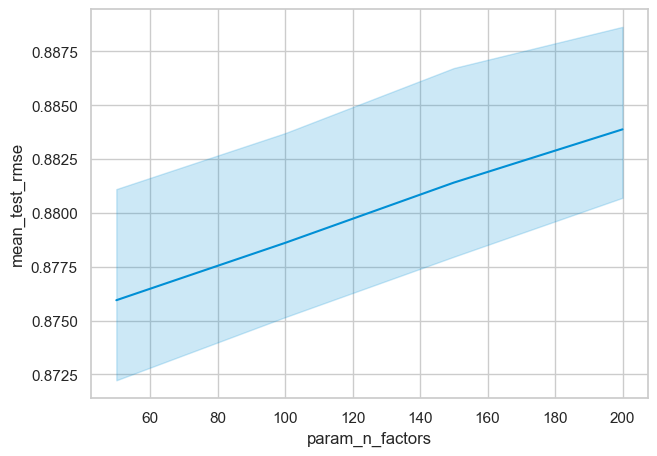

In [240]:
sns.lineplot(svd_results_df,x='param_n_factors', y='mean_test_rmse')

<Axes: xlabel='param_n_epochs', ylabel='mean_test_rmse'>

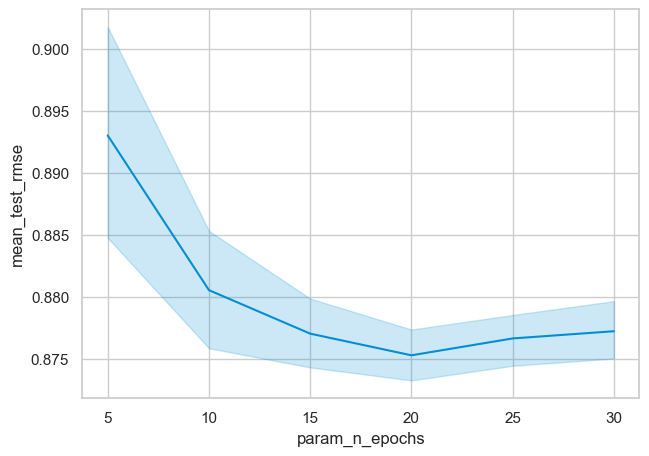

In [241]:
sns.lineplot(svd_results_df,x='param_n_epochs', y='mean_test_rmse')

<Axes: xlabel='param_lr_all', ylabel='mean_test_rmse'>

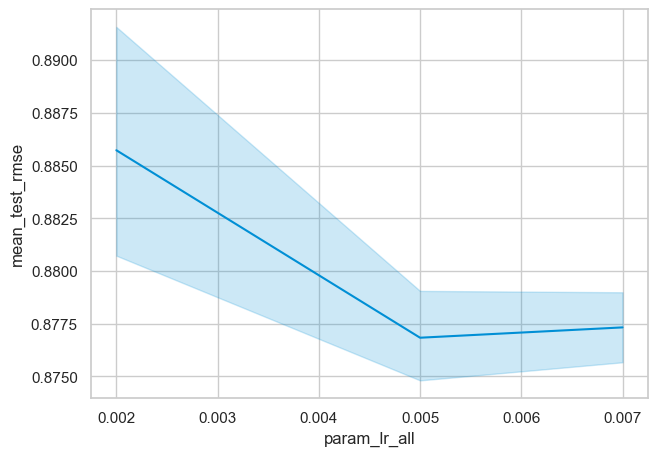

In [242]:
sns.lineplot(svd_results_df,x='param_lr_all', y='mean_test_rmse')

In [102]:
# kNN Basic User
# grid search
print("kNN Basic User Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [True],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNBasic, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNBasicUser_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNBasicUser_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNBasicUser_results_df.head()

kNN Basic User Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.902734,0.915737,0.910227,0.909566,0.005329,1,0.030003,0.000727,0.320220,0.061611,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': True}",False
1,0.931038,0.945491,0.936781,0.937770,0.005941,37,0.052558,0.001926,0.278494,0.022309,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': True}",False
2,0.942703,0.956805,0.953655,0.951054,0.006044,60,0.060388,0.001681,0.307747,0.056554,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': True}",False
3,0.902734,0.915785,0.910220,0.909580,0.005347,2,0.029915,0.002368,0.289722,0.016751,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': True}",False
4,0.931038,0.945537,0.936774,0.937783,0.005962,38,0.056816,0.009482,0.304652,0.029683,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': True}",False


In [161]:
kNNBasicUser_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
0,0.902734,0.915737,0.910227,0.909566,0.005329,1,0.030003,0.000727,0.320220,0.061611,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,False
3,0.902734,0.915785,0.910220,0.909580,0.005347,2,0.029915,0.002368,0.289722,0.016751,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,False
9,0.902954,0.916141,0.909924,0.909673,0.005386,3,0.027838,0.001025,0.248313,0.007519,"{'k': 20, 'min_k': 4, 'sim_options': {'name': ...",20,4,False
6,0.902715,0.916141,0.910220,0.909692,0.005494,4,0.030638,0.002869,0.260032,0.003527,"{'k': 20, 'min_k': 3, 'sim_options': {'name': ...",20,3,False
12,0.903939,0.916769,0.910848,0.910519,0.005243,5,0.029452,0.001624,0.280943,0.016980,"{'k': 30, 'min_k': 1, 'sim_options': {'name': ...",30,1,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

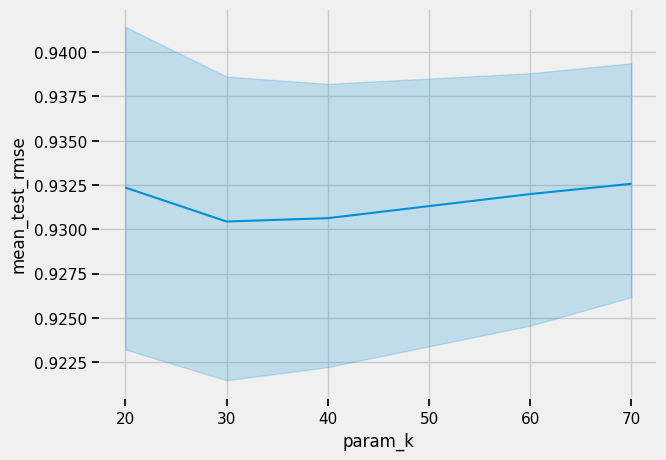

In [121]:
sns.lineplot(kNNBasicUser_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

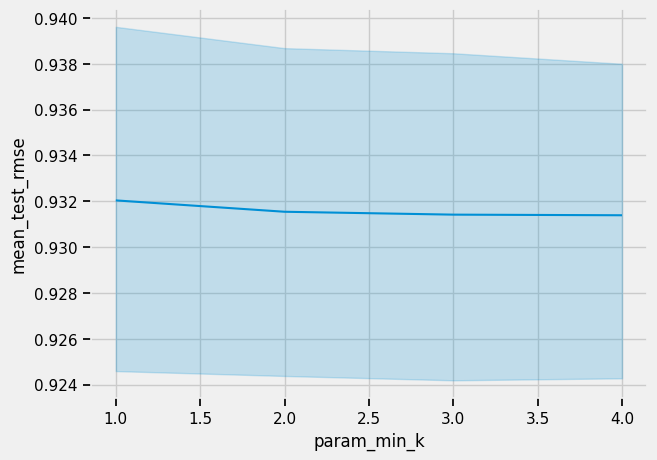

In [125]:
sns.lineplot(kNNBasicUser_results_df,x='param_min_k', y='mean_test_rmse')

In [127]:
kNNBasicUser_results_df2=kNNBasicUser_results_df.join(pd.DataFrame(kNNBasicUser_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

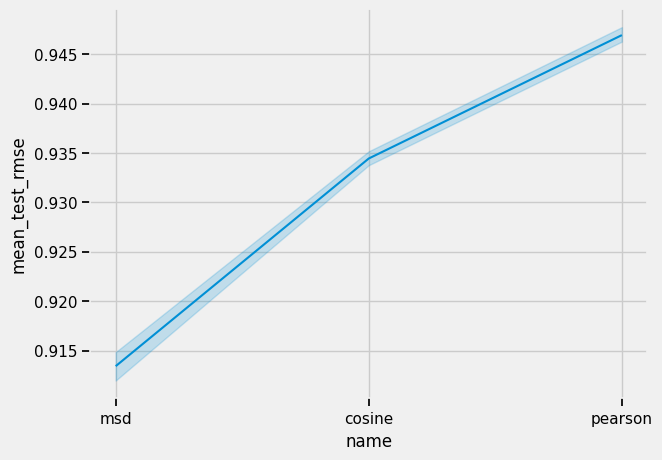

In [130]:
sns.lineplot(kNNBasicUser_results_df2,x='name', y='mean_test_rmse')

In [103]:
# kNN Basic Item
# grid search
print("kNN Basic Item Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [False],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNBasic, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNBasicItem_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNBasicItem_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNBasicItem_results_df.head()

kNN Basic Item Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.902371,0.899904,0.902055,0.901443,0.001096,15,0.043078,0.001086,0.375391,0.055163,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': False}",False
1,0.939800,0.935902,0.936403,0.937368,0.001731,58,0.075140,0.003617,0.326470,0.007576,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': False}",False
2,0.940078,0.936809,0.937888,0.938258,0.001360,60,0.093012,0.008657,0.324973,0.008167,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': False}",False
3,0.902371,0.899790,0.902066,0.901409,0.001152,14,0.039402,0.000439,0.356300,0.048817,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': False}",False
4,0.939800,0.935792,0.936415,0.937336,0.001761,57,0.076904,0.005730,0.328450,0.011723,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': False}",False


In [162]:
kNNBasicItem_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
21,0.898711,0.895519,0.898624,0.897618,0.001485,1,0.039552,0.001051,0.350342,0.009578,"{'k': 30, 'min_k': 4, 'sim_options': {'name': ...",30,4,False
15,0.899537,0.895095,0.898327,0.897653,0.001875,2,0.039475,0.001109,0.370442,0.005657,"{'k': 30, 'min_k': 2, 'sim_options': {'name': ...",30,2,False
33,0.898884,0.894694,0.899423,0.897667,0.002114,3,0.039024,0.000802,0.425954,0.060246,"{'k': 40, 'min_k': 4, 'sim_options': {'name': ...",40,4,False
12,0.899537,0.895209,0.898315,0.897687,0.001822,4,0.039809,0.000260,0.360643,0.008041,"{'k': 30, 'min_k': 1, 'sim_options': {'name': ...",30,1,False
27,0.899710,0.894269,0.899126,0.897702,0.002439,5,0.038585,0.001751,0.377255,0.001417,"{'k': 40, 'min_k': 2, 'sim_options': {'name': ...",40,2,False


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

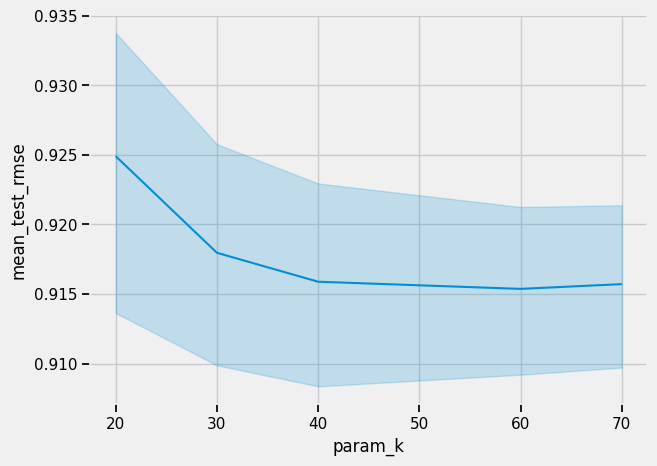

In [131]:
sns.lineplot(kNNBasicItem_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

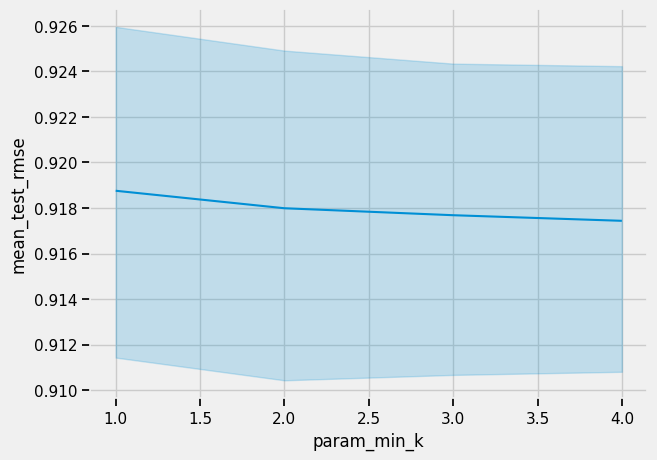

In [132]:
sns.lineplot(kNNBasicItem_results_df,x='param_min_k', y='mean_test_rmse')

In [133]:
kNNBasicItem_results_df2=kNNBasicItem_results_df.join(pd.DataFrame(kNNBasicItem_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

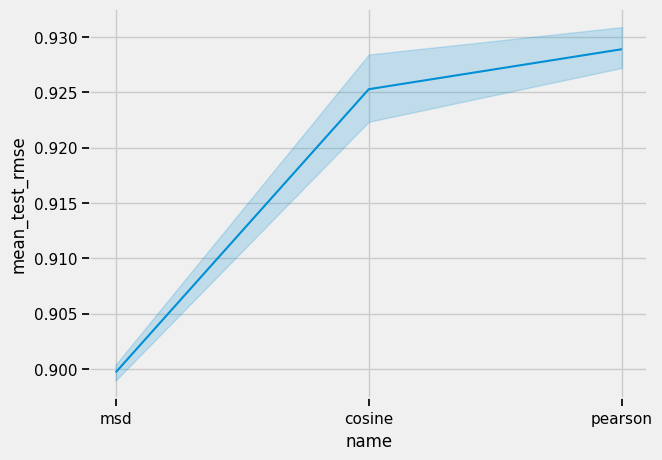

In [134]:
sns.lineplot(kNNBasicItem_results_df2,x='name', y='mean_test_rmse')

In [104]:
# kNN Means User
# grid search
print("kNN Means User Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [True],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNWithMeans, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNMeansUser_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNMeansUser_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNMeansUser_results_df.head()

kNN Means User Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.877243,0.882861,0.874231,0.878112,0.003576,34,0.033329,0.003435,0.314744,0.065201,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': True}",False
1,0.881662,0.885797,0.877589,0.881682,0.003351,38,0.053314,0.001679,0.287268,0.020334,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': True}",False
2,0.889362,0.895519,0.885237,0.890039,0.004225,60,0.060532,0.002237,0.308898,0.051660,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': True}",False
3,0.877243,0.882786,0.874232,0.878087,0.003543,33,0.033393,0.000595,0.277616,0.001824,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': True}",False
4,0.881662,0.885722,0.877590,0.881658,0.003320,37,0.052943,0.002324,0.279439,0.006093,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': True}",False


In [235]:
kNNMeansUser_cv_results_h = cross_validate(kNNMeansUser_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8747  0.8666  0.8616  0.8762  0.8606  0.8679  0.0065  
MAE (testset)     0.6644  0.6584  0.6606  0.6632  0.6559  0.6605  0.0031  
Fit time          0.07    0.09    0.08    0.08    0.10    0.08    0.01    
Test time         0.50    0.56    0.51    0.57    0.51    0.53    0.03    


In [176]:
# pd.set_option('display.width', 500)
pd.set_option('display.max_colwidth', None)
kNNMeansUser_results_df.sort_values('mean_test_rmse')['params'].head()

39    {'k': 60, 'min_k': 2, 'sim_options': {'name': 'msd', 'user_based': True}, 'verbose': False}
36    {'k': 60, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': True}, 'verbose': False}
45    {'k': 60, 'min_k': 4, 'sim_options': {'name': 'msd', 'user_based': True}, 'verbose': False}
42    {'k': 60, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': True}, 'verbose': False}
27    {'k': 40, 'min_k': 2, 'sim_options': {'name': 'msd', 'user_based': True}, 'verbose': False}
Name: params, dtype: object

<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

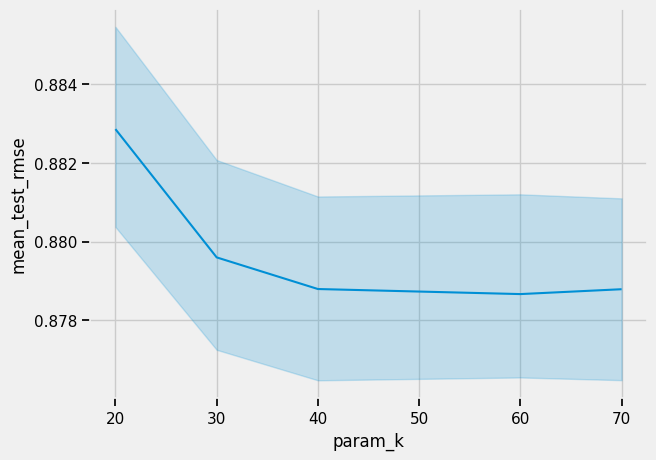

In [135]:
sns.lineplot(kNNMeansUser_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

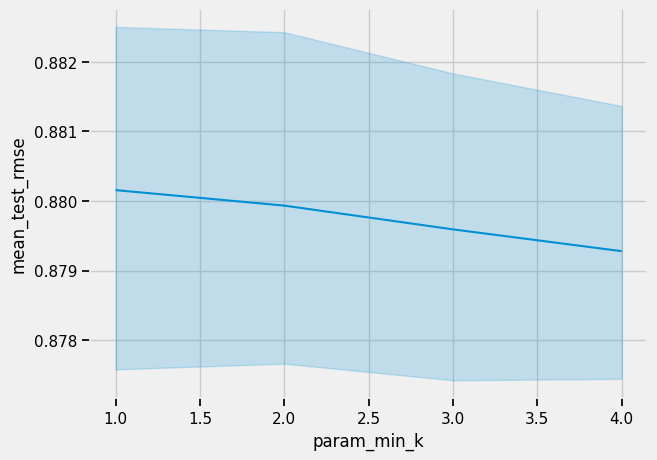

In [136]:
sns.lineplot(kNNMeansUser_results_df,x='param_min_k', y='mean_test_rmse')

In [137]:
kNNMeansUser_results_df2=kNNMeansUser_results_df.join(pd.DataFrame(kNNMeansUser_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

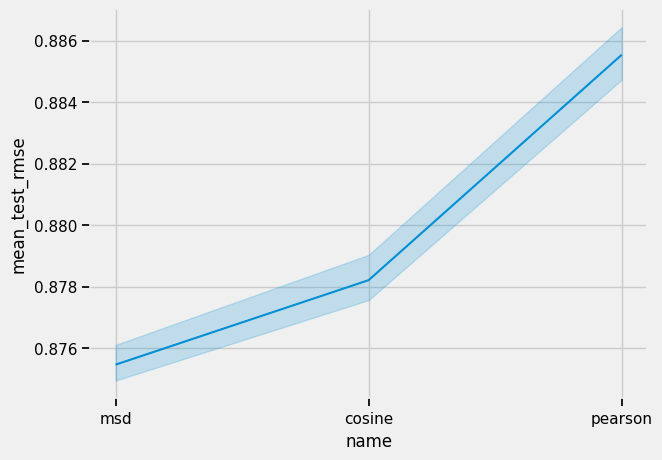

In [138]:
sns.lineplot(kNNMeansUser_results_df2,x='name', y='mean_test_rmse')

In [105]:
# kNN Means Item
# grid search
print("kNN Means Item Grid Search")

param_grid = {

    "k":[20,30,40,60,70],
    "min_k": [1,2,3,4],
    'sim_options': {
        'name': ['msd', 'cosine','pearson'],
        'user_based': [False],
    },
    'verbose':[False]
    }
grid_search = GridSearchCV(KNNWithMeans, param_grid, measures=["rmse"], cv=3)
grid_search.fit(data)
kNNMeansItem_algo = grid_search.best_estimator["rmse"]
# algo.fit(data.build_full_trainset())

kNNMeansItem_results_df = pd.DataFrame.from_dict(grid_search.cv_results)
kNNMeansItem_results_df.head()

kNN Means Item Grid Search


,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_sim_options,param_verbose
0,0.872220,0.868439,0.869048,0.869902,0.001657,29,0.057186,0.002965,0.488668,0.053182,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'msd', 'user_based': False}",False
1,0.879867,0.877917,0.879381,0.879055,0.000829,55,0.095468,0.006814,0.404120,0.009512,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'cosine', 'user_based': False}",False
2,0.882282,0.875906,0.881053,0.879747,0.002762,60,0.111894,0.002665,0.465361,0.059869,"{'k': 20, 'min_k': 1, 'sim_options': {'name': ...",20,1,"{'name': 'pearson', 'user_based': False}",False
3,0.872660,0.868444,0.868779,0.869961,0.001913,30,0.047881,0.004148,0.382555,0.012086,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'msd', 'user_based': False}",False
4,0.880304,0.877922,0.879116,0.879114,0.000972,56,0.083754,0.003294,0.396825,0.026006,"{'k': 20, 'min_k': 2, 'sim_options': {'name': ...",20,2,"{'name': 'cosine', 'user_based': False}",False


In [177]:
kNNMeansItem_results_df.sort_values('mean_test_rmse').head()

,split0_test_rmse,split1_test_rmse,split2_test_rmse,mean_test_rmse,std_test_rmse,rank_test_rmse,mean_fit_time,std_fit_time,mean_test_time,std_test_time,params,param_k,param_min_k,param_verbose
36,0.865055,0.860691,0.864128,0.863291,0.001877,1,0.046737,0.000747,0.597354,0.073103,"{'k': 60, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}, 'verbose': False}",60,1,False
39,0.865499,0.860697,0.863858,0.863351,0.001993,2,0.051113,0.006061,0.591310,0.053800,"{'k': 60, 'min_k': 2, 'sim_options': {'name': 'msd', 'user_based': False}, 'verbose': False}",60,2,False
45,0.865170,0.860926,0.864205,0.863434,0.001816,3,0.053363,0.005518,0.566525,0.013610,"{'k': 60, 'min_k': 4, 'sim_options': {'name': 'msd', 'user_based': False}, 'verbose': False}",60,4,False
48,0.865286,0.860821,0.864204,0.863437,0.001902,4,0.049438,0.001324,0.592035,0.024829,"{'k': 70, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}, 'verbose': False}",70,1,False
42,0.865290,0.860909,0.864212,0.863470,0.001864,5,0.051311,0.003633,0.599003,0.033478,"{'k': 60, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}, 'verbose': False}",60,3,False


In [236]:
kNNMeansItem_cv_results_h = cross_validate(kNNMeansItem_algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True, n_jobs=1)

Evaluating RMSE, MAE of algorithm KNNWithMeans on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8619  0.8329  0.8636  0.8727  0.8614  0.8585  0.0134  
MAE (testset)     0.6519  0.6383  0.6572  0.6638  0.6580  0.6538  0.0086  
Fit time          0.11    0.23    0.13    0.11    0.21    0.16    0.05    
Test time         0.73    0.73    0.74    0.71    0.82    0.75    0.04    


<Axes: xlabel='param_k', ylabel='mean_test_rmse'>

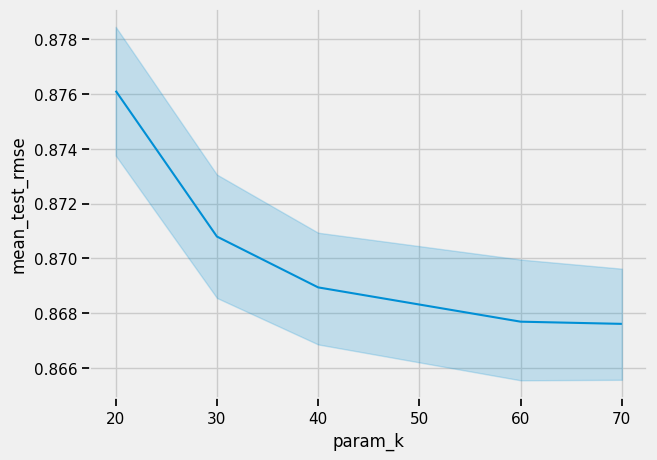

In [139]:
sns.lineplot(kNNMeansItem_results_df,x='param_k', y='mean_test_rmse')

<Axes: xlabel='param_min_k', ylabel='mean_test_rmse'>

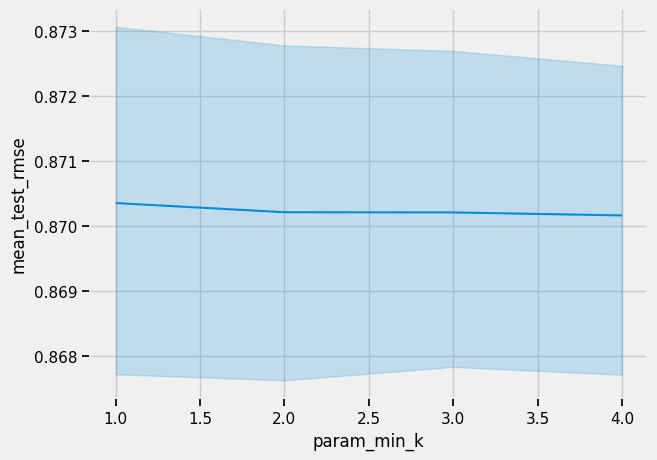

In [140]:
sns.lineplot(kNNMeansItem_results_df,x='param_min_k', y='mean_test_rmse')

In [141]:
kNNMeansItem_results_df2=kNNMeansItem_results_df.join(pd.DataFrame(kNNMeansItem_results_df.pop('param_sim_options').values.tolist()))

<Axes: xlabel='name', ylabel='mean_test_rmse'>

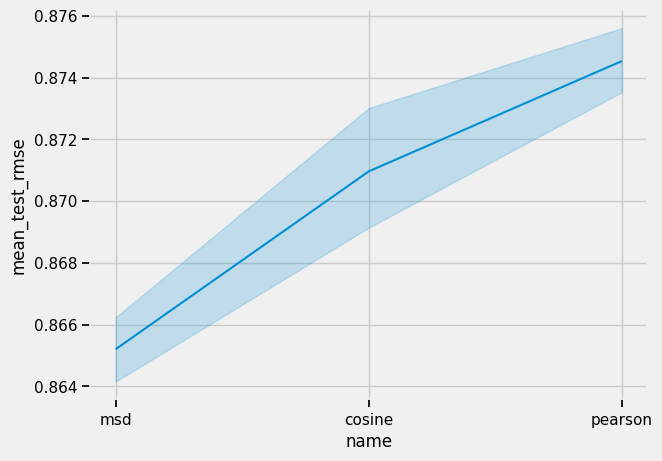

In [142]:
sns.lineplot(kNNMeansItem_results_df2,x='name', y='mean_test_rmse')

### Graph tuned results

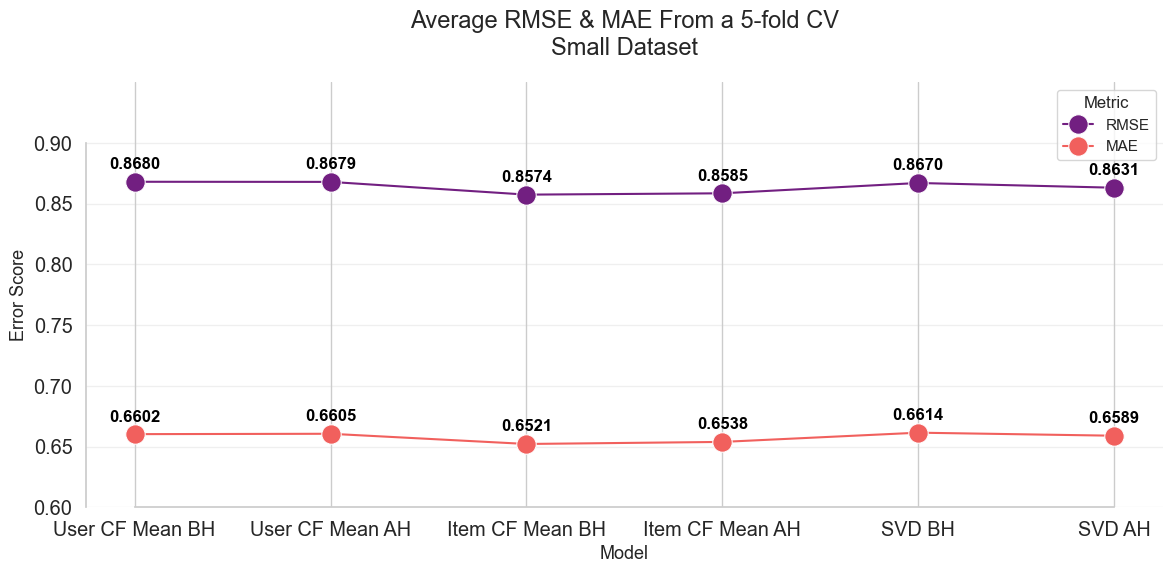

In [ ]:
dplot = {
    'SVD BH':      svd_cv_results,
    'SVD AH':      svd_cv_results_h,
    'User CF Mean BH':kNNMeansUser_cv_results,
    'User CF Mean AH':kNNMeansUser_cv_results_h,
    'Item CF Mean BH':kNNMeansItem_cv_results,
    'Item CF Mean AH':kNNMeansItem_cv_results_h
}

df_list = []
for model_name, result in dplot.items():
    df_temp = pd.DataFrame({
        'test_rmse': result['test_rmse'],
        'test_mae':  result['test_mae']
    })
    df_temp['model'] = model_name
    df_list.append(df_temp)

df_all = pd.concat(df_list, ignore_index=True)

# Calc average per model
means = df_all.groupby('model')[['test_rmse', 'test_mae']].mean().round(4)
means = means.reset_index()

# Melt to long format
plot_df = means.melt(id_vars='model',
                     value_vars=['test_rmse', 'test_mae'],
                     var_name='Metric',
                     value_name='Score')

# Clean names
plot_df['Metric'] = plot_df['Metric'].replace({'test_rmse': 'RMSE', 'test_mae': 'MAE'})

# Order models
model_order = ['User CF Mean BH','User CF Mean AH', 'Item CF Mean BH','Item CF Mean AH', 'SVD BH', 'SVD AH']  
plot_df['model'] = pd.Categorical(plot_df['model'], categories=model_order, ordered=True)
plot_df = plot_df.sort_values('model')

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)

# Lineplot with markers
ax = sns.lineplot(data=plot_df,
                  x='model',
                  y='Score',
                  hue='Metric',
                  marker='o',
                  markersize=14,
                  palette='magma')

# Add values next to each point
for _, row in plot_df.iterrows():
    ax.text(row['model'], 
            row['Score'] + 0.008,
            f'{row["Score"]:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=12, color='black')

ax.set_title('Average RMSE & MAE From a 5-fold CV\nSmall Dataset',
             fontsize=17, pad=20)
ax.set_ylabel('Error Score', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.legend(title='Metric', title_fontsize=12, fontsize=11, loc='upper right')

plt.ylim(0.60, 0.95)
sns.despine(trim=True)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Recommender
Best recommendations for everyone function 

In [ ]:
from collections import defaultdict

def get_top_n_for_everyone(predictions, n=10):

    # Map the predictions to each user.
    top_n = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid].append((iid, est))

    # Sort the predictions for each user and retrieve the best n ones
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n



Fit the model and run the recommender. Top 10 movies

In [ ]:
trainset = data.build_full_trainset()
svd_algo.fit(trainset)
testset = trainset.build_anti_testset()
predictions = svd_algo.test(testset)

top_10 = get_top_n_for_everyone(predictions, n=10)

Add the movie titles to the links dataframe to convert the id to something readable

In [245]:
df_links2 = df_links.merge(df_meta, left_on='tmdbId',right_on='id').drop(columns=['tmdbId','id'])
df_links2.head()


,movieId,title
0,1,Toy Story
1,2,Jumanji
2,3,Grumpier Old Men
3,4,Waiting to Exhale
4,5,Father of the Bride Part II


Show user 2's top recommendations

In [ ]:
movie_titles = dict(zip(df_links2['movieId'], df_links2['title']))

def get_movie_titles(movieIds):
    for i,r in movieIds:
        print(movie_titles[i]," rating: ",r)

get_movie_titles(top_10[2])

The Shawshank Redemption  rating:  4.44664272497892
The African Queen  rating:  4.443975407537229
Cinema Paradiso  rating:  4.381589464650346
The Godfather  rating:  4.326533476935126
The Godfather: Part II  rating:  4.317678418999035
Butch Cassidy and the Sundance Kid  rating:  4.29475375527994
Amadeus  rating:  4.289569237910483
The Imitation Game  rating:  4.281142266073303
To Kill a Mockingbird  rating:  4.279612564139944
Life Is Beautiful  rating:  4.274844568395489


### Reload full dataset to calc learning curve for SVD

In [257]:
# Load the metadata
df_ratings2 = pd.read_csv(data_path+"ratings.csv")
df_ratings2 = df_ratings2[["userId", "movieId", "rating"]]
df_ratings2 = df_ratings2.dropna(subset=["userId", "movieId", "rating"])
df_ratings2["userId"] = df_ratings2["userId"].astype(int) 
df_ratings2["movieId"] = df_ratings2["movieId"].astype(int) 
df_ratings2["rating"] = df_ratings2["rating"].astype(float) 
# If there are duplicate <userId, movieId> pairs, average them. Unlikely tho 
df_ratings2 = df_ratings2.groupby(["userId", "movieId"], as_index=False)["rating"].mean()


df_links2 = pd.read_csv(data_path+"links.csv") 
df_links2 = df_links2[["movieId", "tmdbId"]]
df_links2["tmdbId"] = pd.to_numeric(df_links2["tmdbId"], errors="coerce") 
df_links2 = df_links2.dropna(subset=["tmdbId"]).astype({"tmdbId": int}) 

In [ ]:
# Filter users who have rated too many or too few movies
print("="*50)
print("FILTERING USERS")
print("="*50)

# Count how many movies each user has rated
user_movie_counts = df_ratings2['userId'].value_counts()
print(f"User rating counts - Min: {user_movie_counts.min()}, Max: {user_movie_counts.max()}")

# Remove users who have rated less than 10 movies
min_user_ratings = 10
users_to_keep = user_movie_counts[user_movie_counts >= min_user_ratings].index
print(f"Users with at least {min_user_ratings} ratings: {len(users_to_keep)} out of {len(user_movie_counts)}")

# Remove users who rated too many movies (top 5%)
max_percentile = 95
max_user_ratings = np.percentile(user_movie_counts, max_percentile)
users_to_keep = users_to_keep[user_movie_counts[users_to_keep] <= max_user_ratings]
print(f"Users after removing top 5% (>{max_user_ratings:.0f} ratings): {len(users_to_keep)}")

# Filter the dataset to keep only selected users
ratings_filtered2 = df_ratings2[df_ratings2['userId'].isin(users_to_keep)].copy()
print(f"Ratings after user filtering: {ratings_filtered2.shape}")


FILTERING USERS
User rating counts - Min: 1, Max: 18276
Users with at least 10 ratings: 233903 out of 270896
Users after removing top 5% (>398 ratings): 220391
Ratings after user filtering: (15501527, 3)


In [ ]:
# Filter movies with less than 20 ratings

print("="*50)
print("FILTERING MOVIES")
print("="*50)

# Count how many ratings each movie has received
movie_rating_counts = ratings_filtered2['movieId'].value_counts()
print(f"Movie rating counts - Min: {movie_rating_counts.min()}, Max: {movie_rating_counts.max()}")

# Keep only movies with at least 20 ratings
min_movie_ratings = 20
movies_to_keep = movie_rating_counts[movie_rating_counts >= min_movie_ratings].index
print(f"Movies with at least {min_movie_ratings} ratings: {len(movies_to_keep)} out of {len(movie_rating_counts)}")

# Filter the dataset to keep only selected movies
ratings_final2 = ratings_filtered2[ratings_filtered2['movieId'].isin(movies_to_keep)].copy()
print(f"Final ratings shape: {ratings_final2.shape}")


STEP 2: FILTERING MOVIES
Movie rating counts - Min: 1, Max: 77009
Movies with at least 20 ratings: 10779 out of 28685
Final ratings shape: (15426981, 3)


In [ ]:
# Create index mappings
print("="*50)
print("CREATING INDEX MAPPINGS")
print("="*50)

unique_users = sorted(ratings_final2['userId'].unique())
unique_movies = sorted(ratings_final2['movieId'].unique())

print(f"Final number of users: {len(unique_users)}")
print(f"Final number of movies: {len(unique_movies)}")

user_id_to_index = {user_id: idx for idx, user_id in enumerate(unique_users)}
index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(unique_movies)}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

ratings_final2['user_idx'] = ratings_final2['userId'].map(user_id_to_index)
ratings_final2['movie_idx'] = ratings_final2['movieId'].map(movie_id_to_index)

STEP 3: CREATING INDEX MAPPINGS
Final number of users: 220391
Final number of movies: 10779
Index mappings created successfully!


In [ ]:
# Create the user-movie rating matrix
print("="*50)
print("CREATING USER-MOVIE MATRIX")
print("="*50)

from scipy.sparse import csr_matrix

n_users = len(unique_users)
n_movies = len(unique_movies)

# Convert to numpy arrays for faster indexing
user_indices = ratings_final2['user_idx'].values.astype(int)
movie_indices = ratings_final2['movie_idx'].values.astype(int)
rating_values = ratings_final2['rating'].values.astype(float)

# Create a sparse user-movie matrix using csr_matrix
# Data, (row_indices, col_indices)
user_movie_matrix2 = csr_matrix((rating_values, (user_indices, movie_indices)), shape=(n_users, n_movies))

print(f"User-movie matrix shape: {user_movie_matrix2.shape}")
# Sparsity for csr_matrix can be calculated as 1 - (number of stored elements / total possible elements)
print(f"Matrix sparsity: {(1 - user_movie_matrix2.nnz / (n_users * n_movies)) * 100:.2f}%")

STEP 4: CREATING USER-MOVIE MATRIX
User-movie matrix shape: (220391, 10779)
Matrix sparsity: 99.35%


In [ ]:
print("Loading data into Surprise format...")
reader2 = Reader(rating_scale=(0.5, 5.0))
data2 = Dataset.load_from_df(ratings_final2[['userId', 'movieId', 'rating']], reader2)
print("Data loaded successfully into Surprise Dataset.")

Loading data into Surprise format...
Data loaded successfully into Surprise Dataset.


In [ ]:
# Split and keep a fixed test set
trainset, testset = train_test_split(data2, test_size=0.2, random_state=42)

# Convert global trainset to list of ratings for sampling
all_ratings = [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r) 
               for u, i, r in trainset.all_ratings()]

# Learning curve subsets
train_fractions = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
train_rmses = []
test_rmses  = []

print("Computing learning curve")
for frac in train_fractions:
    print(f"  → Using {frac*100:.0f}% of training data ({int(frac*len(all_ratings)):,} ratings)")

    # Sample subset of ratings
    subset_size = int(frac * len(all_ratings))
    subset_ratings = np.random.choice(len(all_ratings), size=subset_size, replace=False)
    subset_list = [all_ratings[i] for i in subset_ratings]

    # Build a new Trainset from subset
    subset_data = Dataset.load_from_df(
        pd.DataFrame(subset_list, columns=['user_id', 'item_id', 'rating']),
        reader
    )
    subset_trainset = subset_data.build_full_trainset()

    # Train model using hypertuned SVD model we made earlier
    model = svd_algo
    model.fit(subset_trainset)

    # Train rmse
    train_predictions = model.test(subset_trainset.build_testset())
    train_rmse = accuracy.rmse(train_predictions, verbose=False)
    train_rmses.append(train_rmse)

    # Test rmse
    test_predictions = model.test(testset)
    test_rmse = accuracy.rmse(test_predictions, verbose=False)
    test_rmses.append(test_rmse)



Computing learning curve...
  → Using 10% of training data (1,234,158 ratings)
  → Using 20% of training data (2,468,316 ratings)
  → Using 40% of training data (4,936,633 ratings)
  → Using 60% of training data (7,404,950 ratings)
  → Using 80% of training data (9,873,267 ratings)
  → Using 100% of training data (12,341,584 ratings)


Plot our result

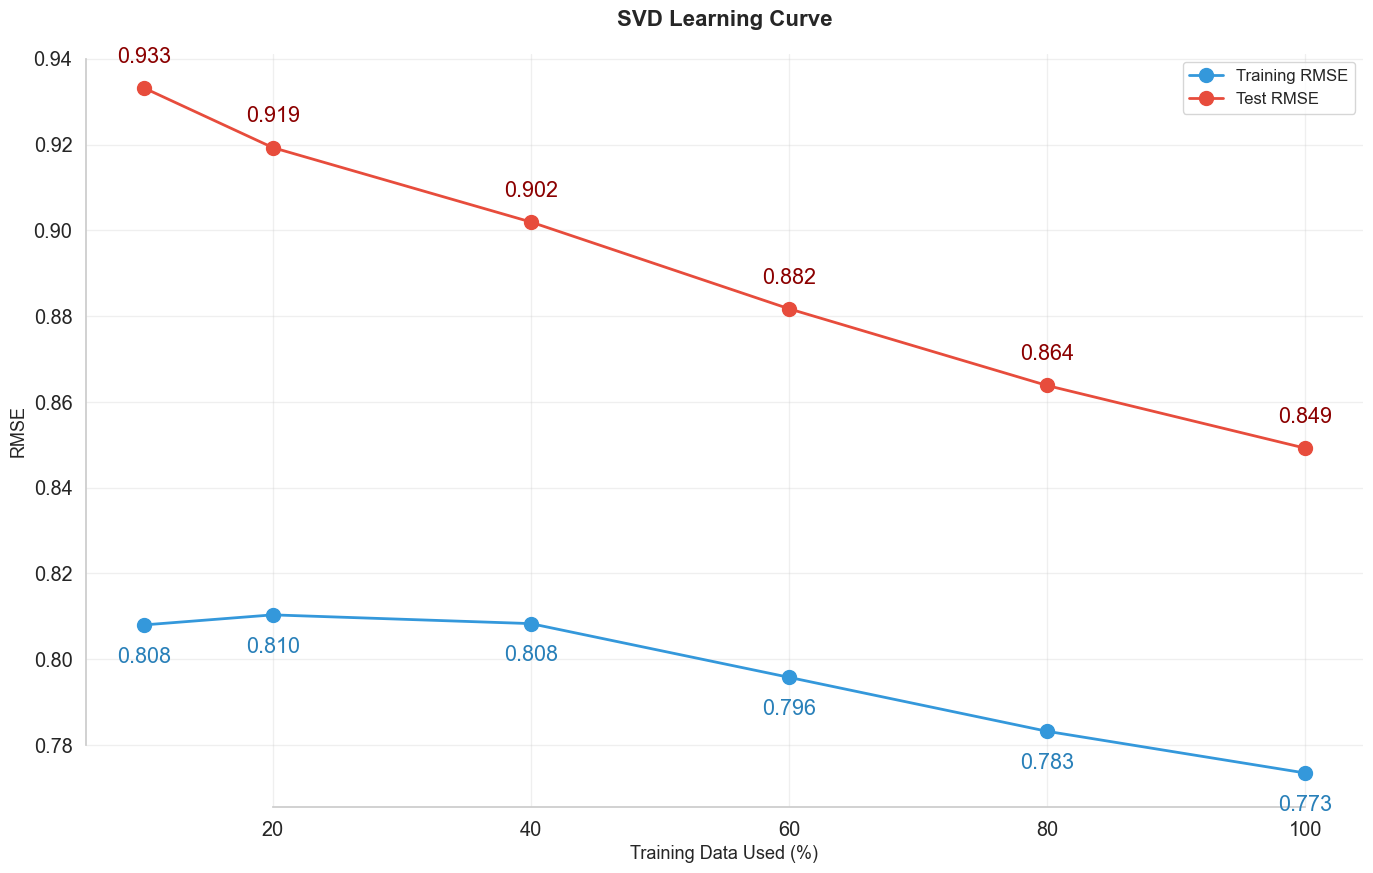

In [ ]:
plt.figure(figsize=(14, 9))

# Red blue values
plt.plot(np.array(train_fractions)*100, train_rmses, 'o-', 
         label='Training RMSE', color='#3498db', linewidth=2, markersize=10)
plt.plot(np.array(train_fractions)*100, test_rmses, 'o-', 
         label='Test RMSE', color='#e74c3c', linewidth=2, markersize=10)

# Add value labels
for x, y_tr, y_te in zip(np.array(train_fractions)*100, train_rmses, test_rmses):
    plt.text(x, y_tr - 0.005, f'{y_tr:.3f}', ha='center', va='top', color='#2980b9')
    plt.text(x, y_te + 0.005, f'{y_te:.3f}', ha='center', va='bottom', color='darkred')

plt.title('SVD Learning Curve', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Training Data Used (%)', fontsize=13)
plt.ylabel('RMSE', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
# plt.ylim(0.80, 0.95)
sns.despine(trim=True)
plt.tight_layout()
plt.show()